# Linear Models: US Firm Characteristics

**Docker image**: `ml4t`

This notebook tests regularized linear models on 57 monthly firm characteristics.
The provider applies its standard annual-June and monthly-next-month timing rules.
Anonymous firm identities remain persistent within each released tensor block, and
the canonical walk-forward folds keep the 2016 holdout sealed.

`PRIMARY_LABEL` selects one declared label per run. The charts and takeaways below
derive from that run instead of mixing results from separate label variants.

**Learning Objectives**:
- Evaluate one declared label without opening the sealed holdout
- Compare regularization approaches (L1, L2, elastic net) for fundamental factor data
- Compare validation information coefficients across the regularization grid
- Generate backtesting-ready predictions for Ch16 strategy simulation

**Book Reference**: Chapter 11, Section 11.2 (Regularized Linear Models)

**Prerequisites**: `03_financial_features.py`, [`04_evaluation`](04_evaluation.ipynb)

In [1]:
"""Linear models with walk-forward cross-validation."""

import time
import warnings
from datetime import UTC, datetime

import numpy as np
import pandas as pd
import polars as pl
import yaml
from IPython.display import Markdown, display
from matplotlib import pyplot as plt
from ml4t.diagnostic.metrics import cross_sectional_ic
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, LogisticRegression, Ridge

from case_studies.utils.registry import (
    build_training_spec,
    get_training_dir,
    load_prediction_metrics,
    load_prediction_sets,
    register_prediction_set,
    register_training_run,
    training_hash_from_spec,
    training_run_status,
)
from utils.modeling import (
    ConfigError,
    load_configs,
    load_modeling_dataset,
    prepare_cv_folds,
    resolve_linear_params,
)
from utils.paths import get_case_study_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, FIGSIZE, add_message_title, zero_line

warnings.filterwarnings("ignore")

In [2]:
CASE_STUDY_ID = "us_firm_characteristics"
PRIMARY_LABEL = ""
MAX_SYMBOLS = 0
FORCE_RETRAIN = False  # Set True to retrain configs that already have complete hashes
PREDICTION_SPLIT = "validation"
TRAIN_SAMPLE_FRAC = 1.0  # <1.0 subsamples training rows per fold (val is never sampled). Use for memory-constrained runs on large datasets.
MAX_FOLDS = 0
SEED = 42

In [3]:
set_global_seeds(SEED)
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
if not PRIMARY_LABEL:
    setup = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())
    PRIMARY_LABEL = setup["labels"]["primary"]

## 1. Load Data and Model Configs

Model configurations are defined in `config/training/{label}.yaml`. Each entry
references a preset in `config/`, which contains the complete estimator
the sklearn class and its constructor parameters. To modify the grid,
edit the label config file: comment out presets or add new ones.

In [4]:
mds = load_modeling_dataset(CASE_STUDY_ID, PRIMARY_LABEL, max_symbols=MAX_SYMBOLS)

dataset = mds.dataset
feature_names = mds.feature_names
label_col = mds.label_col
date_col = mds.date_col
entity_col = mds.entity_cols[0] if mds.entity_cols else None
splits = mds.splits[: MAX_FOLDS or None]

print(f"Dataset: {len(dataset):,} rows × {len(feature_names)} features")
print(f"Label: {label_col} | Task: {mds.task_type} | Folds: {len(splits)}")

Dataset: 804,530 rows × 57 features
Label: fwd_ret_1m | Task: regression | Folds: 10


In [5]:
configs = load_configs(CASE_STUDY_ID, PRIMARY_LABEL, family="linear")

print(f"\n{len(configs)} configs × {len(splits)} folds = {len(configs) * len(splits)} fits\n")
for cfg in configs:
    params_str = (
        ", ".join(f"{k}={v}" for k, v in cfg["params"].items()) if cfg["params"] else "defaults"
    )
    print(f"  {cfg['config_name']:25s}  {cfg['model_class']}({params_str})")


28 configs × 10 folds = 280 fits

  ols                        LinearRegression(defaults)
  ridge_a0.001               Ridge(alpha=0.001)
  ridge_a0.01                Ridge(alpha=0.01)
  ridge_a0.1                 Ridge(alpha=0.1)
  ridge_a1.0                 Ridge(alpha=1.0)
  ridge_a10.0                Ridge(alpha=10.0)
  ridge_a100.0               Ridge(alpha=100.0)
  ridge_a1000.0              Ridge(alpha=1000.0)
  ridge_a10000.0             Ridge(alpha=10000.0)
  ridge_a100000.0            Ridge(alpha=100000.0)
  ridge_a1000000.0           Ridge(alpha=1000000.0)
  ridge_a10000000.0          Ridge(alpha=10000000.0)
  lasso_f0.5                 Lasso(alpha_frac=0.5, max_iter=5000)
  lasso_f0.2                 Lasso(alpha_frac=0.2, max_iter=5000)
  lasso_f0.08                Lasso(alpha_frac=0.08, max_iter=5000)
  lasso_f0.03                Lasso(alpha_frac=0.03, max_iter=5000)
  lasso_f0.015               Lasso(alpha_frac=0.015, max_iter=5000)
  lasso_f0.35                Lasso(alp

## 2. Prepare CV Folds

Each fold preprocesses training data (median imputation for missing features,
standard scaling) and applies the same transformation to the validation set.

In [6]:
dataset_pd = dataset.to_pandas()
folds = prepare_cv_folds(
    dataset_pd,
    splits,
    feature_names,
    label_col,
    date_col,
    entity_col,
    temporal_by_fold=mds.temporal_by_fold,
    temporal_keys=mds.temporal_keys,
    temporal_feature_names=mds.temporal_feature_names,
    train_sample_frac=TRAIN_SAMPLE_FRAC,
    eval_label_col=mds.eval_label_col,
)

for f in folds:
    print(f"  Fold {f['fold']}: train={f['n_train']:,}  val={f['n_val']:,}")

  Fold 0: train=282,957  val=22,646
  Fold 1: train=291,956  val=23,236
  Fold 2: train=297,570  val=24,092
  Fold 3: train=302,382  val=24,759
  Fold 4: train=304,305  val=24,870
  Fold 5: train=307,854  val=25,285
  Fold 6: train=314,211  val=25,523
  Fold 7: train=318,921  val=25,834
  Fold 8: train=321,953  val=26,885
  Fold 9: train=320,010  val=28,878


## 3. Walk-Forward Cross-Validation

For each configuration, fit the model on each training fold and predict
the validation fold. Cross-sectional IC (Spearman rank correlation per
date, averaged) measures predictive quality.

In [7]:
MODEL_CLASSES = {
    "LinearRegression": LinearRegression,
    "Ridge": Ridge,
    "Lasso": Lasso,
    "ElasticNet": ElasticNet,
    "LogisticRegression": LogisticRegression,
}

Every configuration follows one result schema, whether it is trained, cached, or
degenerate. This keeps ranking and registration independent of the execution path.

In [8]:
def _result_record(
    cfg,
    predictions,
    ic_mean,
    ic_std,
    fold_ics,
    *,
    coefficients=None,
    degenerate=False,
    cached=False,
    started_at=None,
    elapsed_s=0.0,
):
    result = {
        "config": cfg,
        "predictions": predictions,
        "ic_mean": ic_mean,
        "ic_std": ic_std,
        "fold_ics": fold_ics,
        "degenerate": degenerate,
        "cached": cached,
        "started_at": started_at,
        "elapsed_s": elapsed_s,
    }
    if coefficients is not None:
        result["coefficients"] = coefficients
    return result

The constructor resolver adds fold-specific regularization parameters and reports
malformed presets with the configuration name that caused the failure.

In [9]:
def _model_for_fold(cfg, fold):
    cls = MODEL_CLASSES.get(cfg["model_class"])
    if cls is None:
        raise ConfigError(
            f"Unknown model_class '{cfg['model_class']}' in preset '{cfg['config_name']}'.\n"
            f"Available: {list(MODEL_CLASSES.keys())}"
        )
    try:
        params = resolve_linear_params(cfg, fold["X_train"], fold["y_train"])
        if cls is LogisticRegression:
            params["random_state"] = SEED
        return cls(**params)
    except TypeError as exc:
        raise ConfigError(
            f"Cannot create {cfg['model_class']} from preset '{cfg['config_name']}'.\n"
            f"Check preset params for {cfg['config_name']}: {exc}"
        ) from exc

Coefficients are saved by fold so the results section can show both direction and
stability. The intercept is retained in the artifact but excluded from the chart.

In [10]:
def _coefficient_rows(model, cfg, fold_id):
    if not hasattr(model, "coef_"):
        return []

    coefficients = model.coef_.ravel() if model.coef_.ndim > 1 else model.coef_
    intercept = model.intercept_ if np.isscalar(model.intercept_) else model.intercept_[0]
    rows = [
        {
            "config_name": cfg["config_name"],
            "fold": fold_id,
            "feature": feature,
            "coefficient": float(coefficient),
        }
        for feature, coefficient in zip(feature_names, coefficients, strict=False)
    ]
    rows.append(
        {
            "config_name": cfg["config_name"],
            "fold": fold_id,
            "feature": "_intercept_",
            "coefficient": float(intercept),
        }
    )
    return rows

Each validation fold produces one prediction panel and one cross-sectional IC.
Classification IC uses the continuous return behind the discrete target.

In [11]:
def _predict_and_score(model, fold):
    if mds.task_type == "classification" and hasattr(model, "predict_proba"):
        probabilities = model.predict_proba(fold["X_val"])
        predictions = probabilities @ np.array(sorted(mds.class_values), dtype=np.float64)
    else:
        predictions = model.predict(fold["X_val"])

    ic_target = fold["y_eval"] if mds.eval_label_col else fold["y_val"]
    ic_frame = pl.DataFrame(
        {
            "timestamp": fold["dates"],
            "symbol": fold["entities"],
            "y_true": ic_target,
            "y_pred": predictions,
        }
    )
    ic = cross_sectional_ic(
        ic_frame,
        ic_frame,
        pred_col="y_pred",
        ret_col="y_true",
        date_col="timestamp",
        entity_col="symbol",
        min_obs=5,
    )["ic_mean"]

    prediction_frame = fold["meta"][mds.join_cols].copy()
    prediction_frame["fold"] = fold["fold"]
    prediction_frame["prediction"] = predictions
    prediction_frame["actual"] = fold["y_val"]
    if mds.eval_label_col:
        prediction_frame["eval_actual"] = fold["y_eval"]
    return prediction_frame, ic

A complete cached run can render without retraining. Partial runs or runs missing
validation predictions return to the normal fit path.

In [12]:
def _cached_linear_result(cfg):
    spec = build_training_spec(
        cfg["family"],
        cfg["config_name"],
        label_col,
        n_folds=len(folds),
        seed=SEED,
        train_sample_frac=TRAIN_SAMPLE_FRAC,
    )
    status = training_run_status(CASE_STUDY_ID, spec)
    training_hash = training_hash_from_spec(spec)
    split_rows = load_prediction_sets(
        CASE_STUDY_ID,
        training_hash=training_hash,
        split=PREDICTION_SPLIT,
    )
    split_complete = not split_rows.is_empty()
    if not (status.complete and split_complete and not FORCE_RETRAIN):
        if status.complete and not split_complete:
            print(f"  {cfg['config_name']:25s}  RETRAIN: missing {PREDICTION_SPLIT} predictions")
        elif status.partial:
            print(f"  {cfg['config_name']:25s}  RETRAIN: partial state: {status.summary()}")
        return None

    prediction_hash = split_rows["prediction_hash"][0]
    metrics = load_prediction_metrics(CASE_STUDY_ID, prediction_hash=prediction_hash)
    ic_mean = float(metrics["ic_mean"][0]) if not metrics.is_empty() else np.nan
    ic_std = float(metrics["ic_std"][0]) if not metrics.is_empty() else np.nan
    print(f"  {cfg['config_name']:25s}  IC={ic_mean:+.4f} ± {ic_std:.4f}  (cached)")
    return _result_record(
        cfg,
        pd.DataFrame(),
        ic_mean,
        ic_std,
        [],
        cached=True,
    )

Fresh configurations fit once per canonical fold. A setting whose coefficients all
collapse to zero is recorded as degenerate and never registered as a prediction set.

In [13]:
def _fit_linear_config(cfg):
    started_at = datetime.now(UTC).isoformat()
    start = time.perf_counter()
    fold_predictions, fold_ics, coefficients = [], [], []
    for fold in folds:
        model = _model_for_fold(cfg, fold)
        model.fit(fold["X_train"], fold["y_train"])
        if hasattr(model, "coef_") and np.all(model.coef_ == 0):
            elapsed = time.perf_counter() - start
            print(f"  {cfg['config_name']:25s}  SKIP: all coefficients zero")
            return _result_record(
                cfg,
                pd.DataFrame(),
                np.nan,
                np.nan,
                [],
                degenerate=True,
                started_at=started_at,
                elapsed_s=elapsed,
            )
        coefficients.extend(_coefficient_rows(model, cfg, fold["fold"]))
        prediction_frame, ic = _predict_and_score(model, fold)
        fold_predictions.append(prediction_frame)
        fold_ics.append(ic)
    elapsed = time.perf_counter() - start
    ic_mean, ic_std = float(np.nanmean(fold_ics)), float(np.nanstd(fold_ics))
    print(f"  {cfg['config_name']:25s}  IC={ic_mean:+.4f} ± {ic_std:.4f}  ({elapsed:.1f}s)")
    return _result_record(
        cfg,
        pd.concat(fold_predictions, ignore_index=True),
        ic_mean,
        ic_std,
        fold_ics,
        coefficients=coefficients,
        started_at=started_at,
        elapsed_s=elapsed,
    )

In [14]:
results = []
for cfg in configs:
    cached_result = _cached_linear_result(cfg)
    results.append(cached_result if cached_result is not None else _fit_linear_config(cfg))

  ols                        IC=-0.0048 ± 0.0260  (cached)
  ridge_a0.001               IC=-0.0048 ± 0.0260  (cached)
  ridge_a0.01                IC=-0.0048 ± 0.0260  (cached)
  ridge_a0.1                 IC=-0.0048 ± 0.0260  (cached)
  ridge_a1.0                 IC=-0.0048 ± 0.0260  (cached)
  ridge_a10.0                IC=-0.0048 ± 0.0260  (cached)
  ridge_a100.0               IC=-0.0048 ± 0.0259  (cached)
  ridge_a1000.0              IC=-0.0050 ± 0.0259  (cached)
  ridge_a10000.0             IC=-0.0057 ± 0.0257  (cached)
  ridge_a100000.0            IC=-0.0104 ± 0.0268  (cached)
  ridge_a1000000.0           IC=-0.0284 ± 0.0273  (cached)
  ridge_a10000000.0          IC=-0.0409 ± 0.0288  (cached)
  lasso_f0.5                 IC=-0.0100 ± 0.0269  (cached)
  lasso_f0.2                 IC=-0.0082 ± 0.0271  (cached)
  lasso_f0.08                IC=-0.0059 ± 0.0266  (cached)
  lasso_f0.03                IC=-0.0054 ± 0.0262  (cached)
  lasso_f0.015               IC=-0.0054 ± 0.0261  (cache

## 4. Results Summary

Rank configs by mean IC. Group by model family (OLS, Ridge, Lasso, ElasticNet)
and identify the leading regularization strength.

In [15]:
results.sort(key=lambda r: r["ic_mean"] if np.isfinite(r["ic_mean"]) else -np.inf, reverse=True)

active = [r for r in results if not r.get("degenerate")]
degenerate = [r for r in results if r.get("degenerate")]

summary = pl.DataFrame(
    {
        "config": [r["config"]["config_name"] for r in active],
        "ic_mean": [r["ic_mean"] for r in active],
        "ic_fold_std": [r["ic_std"] for r in active],
        "cached": [r.get("cached", False) for r in active],
    }
).sort("ic_mean", descending=True)

if degenerate:
    print(f"Skipped ({len(degenerate)} degenerate, all coefficients zero):")
    for r in degenerate:
        print(f"  {r['config']['config_name']}")

best = active[0] if active else None
summary

config,ic_mean,ic_fold_std,cached
str,f64,f64,bool
"""lasso_f0.85""",-0.003594,0.030888,true
"""enet_f0.85""",-0.003595,0.030888,true
"""ridge_a0.01""",-0.0048,0.025954,true
"""ridge_a0.001""",-0.0048,0.025954,true
"""ols""",-0.0048,0.025954,true
…,…,…,…
"""lasso_f0.35""",-0.010209,0.027452,true
"""enet_f0.35""",-0.01023,0.02746,true
"""ridge_a100000.0""",-0.010357,0.026786,true


### Validation IC across the regularization grid

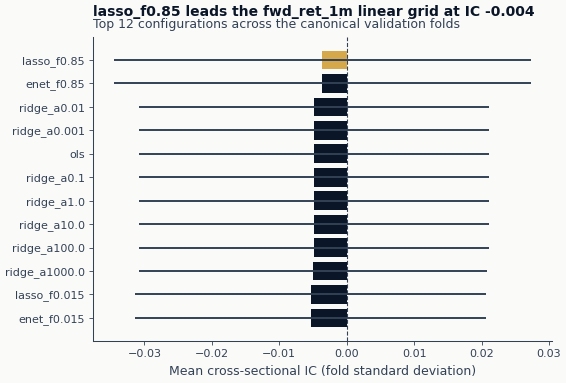

In [16]:
plot_summary = summary.head(12).sort("ic_mean")
leader_name = best["config"]["config_name"] if best else "none"
leader_ic = best["ic_mean"] if best else float("nan")
bar_colors = [
    COLORS["amber"] if name == leader_name else COLORS["blue"]
    for name in plot_summary["config"].to_list()
]

fig, ax = plt.subplots(figsize=FIGSIZE["single_tall"])
ax.barh(
    plot_summary["config"].to_list(),
    plot_summary["ic_mean"].to_list(),
    xerr=plot_summary["ic_fold_std"].to_list(),
    color=bar_colors,
    ecolor=COLORS["neutral"],
    capsize=2,
)
zero_line(ax, axis="x")
ax.set_xlabel("Mean cross-sectional IC (fold standard deviation)")
ax.set_ylabel("")
add_message_title(
    ax,
    f"{leader_name} leads the {PRIMARY_LABEL} linear grid at IC {leader_ic:+.3f}",
    subtitle="Top 12 configurations across the canonical validation folds",
)
fig.tight_layout()
plt.show()

### Coefficients behind the leading model

Fold dispersion shows whether the leading model relies on stable characteristic
weights or on coefficients that change sharply across validation windows.

In [17]:
if best:
    best_spec = build_training_spec(
        best["config"]["family"],
        best["config"]["config_name"],
        label_col,
        n_folds=len(folds),
        seed=SEED,
        train_sample_frac=TRAIN_SAMPLE_FRAC,
    )
    best_coef_path = get_training_dir(CASE_STUDY_ID, best_spec) / "coefficients.parquet"
    best_coef_rows = best.get("coefficients", [])
    if best_coef_rows:
        best_coefs = pl.from_pandas(pd.DataFrame(best_coef_rows))
    elif best_coef_path.exists():
        best_coefs = pl.read_parquet(best_coef_path)
    else:
        best_coefs = pl.DataFrame()
else:
    best_coefs = pl.DataFrame()

Rank characteristics by their mean absolute coefficient across folds. The chart
retains the signed mean so direction and stability remain visible together.

In [18]:
if not best_coefs.is_empty():
    coef_summary = (
        best_coefs.filter(pl.col("feature") != "_intercept_")
        .group_by("feature")
        .agg(
            pl.col("coefficient").mean().alias("mean_coefficient"),
            pl.col("coefficient").abs().mean().alias("mean_abs_coefficient"),
            pl.col("coefficient").std().fill_null(0.0).alias("fold_std"),
        )
        .filter(pl.col("mean_abs_coefficient") > 1e-8)
        .top_k(12, by="mean_abs_coefficient")
        .sort("mean_coefficient")
    )
else:
    coef_summary = pl.DataFrame()

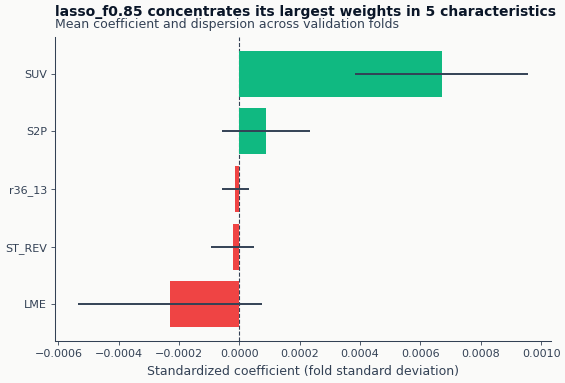

In [19]:
if not coef_summary.is_empty():
    coef_colors = [
        COLORS["positive"] if value >= 0 else COLORS["negative"]
        for value in coef_summary["mean_coefficient"].to_list()
    ]
    fig, ax = plt.subplots(figsize=FIGSIZE["single_tall"])
    ax.barh(
        coef_summary["feature"].to_list(),
        coef_summary["mean_coefficient"].to_list(),
        xerr=coef_summary["fold_std"].to_list(),
        color=coef_colors,
        ecolor=COLORS["neutral"],
        capsize=2,
    )
    zero_line(ax, axis="x")
    ax.set_xlabel("Standardized coefficient (fold standard deviation)")
    ax.set_ylabel("")
    add_message_title(
        ax,
        f"{leader_name} concentrates its largest weights in {coef_summary.height} characteristics",
        subtitle="Mean coefficient and dispersion across validation folds",
    )
    fig.tight_layout()
    plt.show()
else:
    display(Markdown("Coefficient artifacts are unavailable for this cached run."))

## 5. Register Results

Each config is registered in the unified registry with its predictions,
IC metrics, and full provenance (training hash = SHA256 of config + label
+ features + folds). Identical configs produce the same hash, so re-running
updates rather than duplicates.

In [20]:
for r in active:
    if r.get("cached"):
        continue  # already registered on a prior run; predictions not reloaded
    cfg = r["config"]
    spec = build_training_spec(
        cfg["family"],
        cfg["config_name"],
        label_col,
        n_folds=len(folds),
        seed=SEED,
        train_sample_frac=TRAIN_SAMPLE_FRAC,
    )
    t_hash = register_training_run(
        CASE_STUDY_ID,
        spec=spec,
        entry_point="05_linear",
        started_at=r.get("started_at"),
        elapsed_s=r.get("elapsed_s"),
    )

    # Save coefficients to registry training dir
    train_dir = get_training_dir(CASE_STUDY_ID, spec)
    coefs = r.get("coefficients", [])
    if coefs:
        pd.DataFrame(coefs).to_parquet(train_dir / "coefficients.parquet", index=False)

    metrics = {"ic_mean": r["ic_mean"], "ic_std": r["ic_std"]}
    register_prediction_set(
        CASE_STUDY_ID,
        t_hash,
        split=PREDICTION_SPLIT,
        predictions=r["predictions"],
        task_type=mds.task_type,
        eval_col="eval_actual" if mds.eval_label_col else None,
        class_values=mds.class_values or None,
        metrics=metrics,
    )
    print(f"  registered {cfg['config_name']:25s}  IC={r['ic_mean']:+.4f}")

## 6. Key Takeaways

In [21]:
if best:
    sign_text = "positive" if leader_ic > 0 else "negative" if leader_ic < 0 else "zero"
    coefficient_text = (
        f"The chart reports {coef_summary.height} nonzero characteristic weights."
        if not coef_summary.is_empty()
        else "This execution has no coefficient artifact to inspect."
    )
    display(
        Markdown(
            f"- **Leader:** `{leader_name}` leads the `{PRIMARY_LABEL}` run with validation IC "
            f"{leader_ic:+.4f}.\n"
            f"- **Stability:** The estimate is {sign_text}, with fold dispersion "
            f"{best['ic_std']:.4f}.\n"
            f"- **Model structure:** {coefficient_text}\n"
            "- **Validation boundary:** The comparison uses the canonical walk-forward folds and "
            "does not open the sealed 2016 holdout.\n\n"
            "**Next:** [`06_gbm`](06_gbm.ipynb) tests whether non-linear interactions improve "
            "this label-specific baseline. See Chapter 11, Section 11.2 for regularized linear "
            "models."
        )
    )

- **Leader:** `lasso_f0.85` leads the `fwd_ret_1m` run with validation IC -0.0036.
- **Stability:** The estimate is negative, with fold dispersion 0.0309.
- **Model structure:** The chart reports 5 nonzero characteristic weights.
- **Validation boundary:** The comparison uses the canonical walk-forward folds and does not open the sealed 2016 holdout.

**Next:** [`06_gbm`](06_gbm.ipynb) tests whether non-linear interactions improve this label-specific baseline. See Chapter 11, Section 11.2 for regularized linear models.